# Training HGQ models


## Transformer

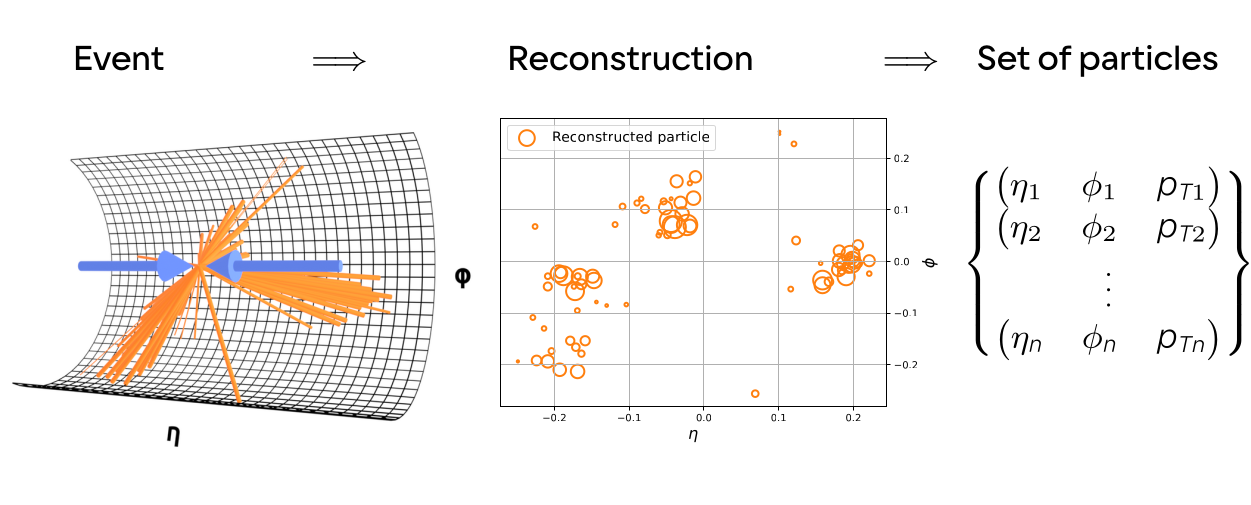



*   Set of particles as transformer input
*   Ordered by pT
*   HGQ utilizes heterogeneous quantization on datalane: breaking permutation invariance



## Multi-Head Attention computation



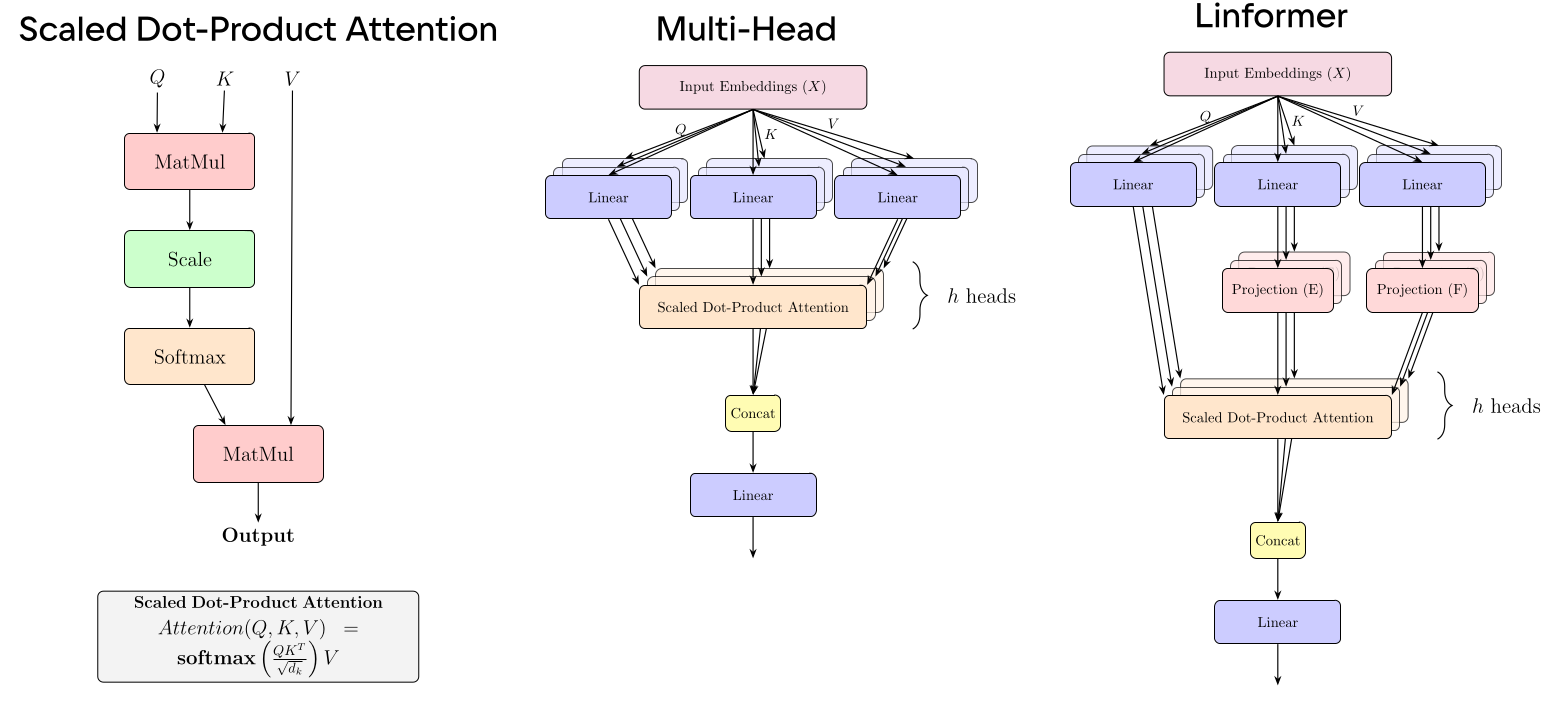



*   Multi-Head Attention $$\mathcal{O}(n^2) $$ with the input
*   MatMul is not a CMVM operation -> no optimization
*   Linformer projects the input resulting to better FPGA implementation $$\mathcal{O}(n \cdot k) $$


https://arxiv.org/abs/2510.24784



## Architectures

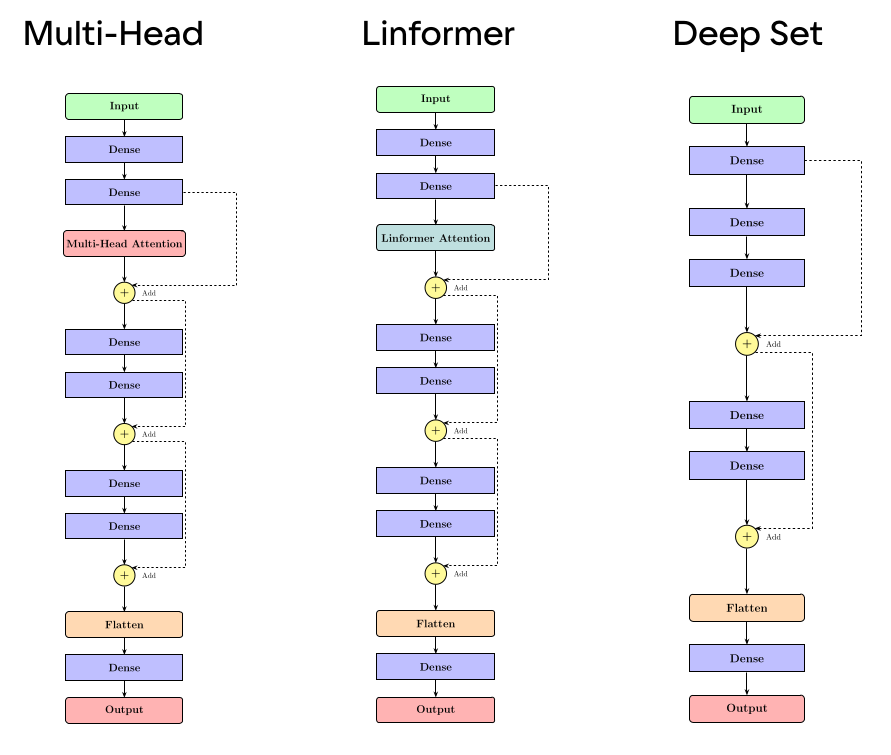

### Download data and install packages

In [1]:
!mkdir data
!wget -P data/ https://www.hep.ph.ic.ac.uk/~llaatu/Collide_X.npy
!wget -P data/ https://www.hep.ph.ic.ac.uk/~llaatu/Collide_y.npy

--2026-03-27 12:07:34--  https://www.hep.ph.ic.ac.uk/~llaatu/Collide_X.npy
Resolving www.hep.ph.ic.ac.uk (www.hep.ph.ic.ac.uk)... 146.179.108.103, 2a0c:5bc0:88:111:216:3eff:fe7f:177
Connecting to www.hep.ph.ic.ac.uk (www.hep.ph.ic.ac.uk)|146.179.108.103|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 144920576 (138M)
Saving to: ‘data/Collide_X.npy’

Collide_X.npy       100%[===================>] 138.21M  21.5MB/s    in 7.4s    

2026-03-27 12:07:42 (18.8 MB/s) - ‘data/Collide_X.npy’ saved [144920576/144920576]

--2026-03-27 12:07:43--  https://www.hep.ph.ic.ac.uk/~llaatu/Collide_y.npy
Resolving www.hep.ph.ic.ac.uk (www.hep.ph.ic.ac.uk)... 146.179.108.103, 2a0c:5bc0:88:111:216:3eff:fe7f:177
Connecting to www.hep.ph.ic.ac.uk (www.hep.ph.ic.ac.uk)|146.179.108.103|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1509716 (1.4M)
Saving to: ‘data/Collide_y.npy’

Collide_y.npy       100%[===================>]   1.44M  1.76MB/s    in 0.8s    



In [2]:

!pip install -q jax

!pip install -q hgq2
!pip install -q hls4ml
!pip install -q da4ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 696.9/696.9 kB 15.9 MB/s eta 0:00:00


In [3]:
import os

# Set JAX as Keras backend
os.environ['KERAS_BACKEND'] = 'jax'
os.environ['JAX_PLATFORMS'] = 'cuda'

import sys
import warnings
import h5py
import numpy as np
from glob import glob

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import layers, models, regularizers
from keras.optimizers import Adam
from keras.optimizers.schedules import CosineDecay
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import load_model
from keras import Model
from sklearn.decomposition import PCA



import jax
import keras
from keras import ops
from keras.models import Model
from keras.callbacks import Callback, ReduceLROnPlateau, TerminateOnNaN
from keras.layers import GlobalAveragePooling1D, Flatten
from keras.optimizers import AdamW

# HGQ Imports
import hgq
from hgq.config import LayerConfigScope, QuantizerConfigScope, QuantizerConfig
from hgq.layers import QMultiHeadAttention, QDense, QAdd, QLinformerAttention, QEinsumDenseBatchnorm, QSum
from hgq.utils.sugar import FreeEBOPs, PBar, BetaPID, EarlyStoppingWithEbopsThres
from hgq.regularizers import MonoL1


In [4]:

# Define any common variables
label_map = {
    'QCD': 0,
    'HH4b': 1,
    'Z+Jets': 2,
    'W+Jets': 3
}

color_map = {
    'QCD': 'blue',
    'HH4b': 'orange',
    'Z+Jets': 'green',
    'W+Jets': 'red'
}

# Function to prepare the dataset for training and testing
# This will also apply a per-feature normalization which is crucial for training neural networks effectively.
def prep_physics_data(X, y, num_particles=10, test_size=0.2, random_state=42):
    # 1. Select the Top K most energetic particles
    # Since particles are already sorted descending by pT, we just slice the array
    X = X[:, :num_particles, :]

    # 2. Scramble (Shuffle) the dataset
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    X = X[indices]
    y = y[indices]

    # 3. Train-Test Split
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # 4. Per-Feature Normalization (Safeguarded against padding)
    # We create a mask identifying where the real particles are (e.g., pT != 0)
    train_mask = (X_train[..., 0] != 0)[..., np.newaxis]
    test_mask = (X_test[..., 0] != 0)[..., np.newaxis]

    # Calculate mean and std ONLY using the training set to prevent data leakage.
    # We take the mean across the batch (0) and particle (1) dimensions.
    mean = np.mean(X_train, axis=(0, 1), keepdims=True)
    std = np.std(X_train, axis=(0, 1), keepdims=True)

    # Prevent division by zero just in case a feature is totally empty
    std = np.where(std == 0, 1e-7, std)

    # Normalize
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    # RE-MASK: Force the padded particles back to exactly 0.0
    X_train = X_train * train_mask
    X_test = X_test * test_mask

    return X_train, X_test, y_train, y_test


# Custom DataLoader for Keras that handles our 3D particle data and supports optional flattening
class ParticleDataLoader(keras.utils.PyDataset):
    def __init__(self, X_data, y_data, batch_size=256, flatten=False, **kwargs):
        super().__init__(**kwargs)

        # Flatten the entire dataset once during initialization
        if flatten:
            # Reshape from (Total_Events, num_particles, features)
            # to (Total_Events, num_particles * features)
            self.X_data = X_data.reshape(X_data.shape[0], -1)
        else:
            self.X_data = X_data

        self.y_data = y_data
        self.batch_size = batch_size

    def __len__(self):
        # Defines the number of batches per epoch
        return int(np.ceil(len(self.X_data) / self.batch_size))

    def __getitem__(self, idx):
        # Fetch the batch slice
        start_idx = idx * self.batch_size
        end_idx = start_idx + self.batch_size

        # The data is already in the correct shape, so we just slice it
        batch_x = self.X_data[start_idx:end_idx]
        batch_y = self.y_data[start_idx:end_idx]

        return batch_x, batch_y


# Patch for hls4ml for nicely formatting the model summary
def patched_make_html_table_template(table_header, row_templates):
    """Hotfix for broken table creation"""
    num_columns = len(next(iter(row_templates.values())))

    _row_html_template = '        <tr><td>{}</td>' + ''.join('<td>{{{}}}</td>' for _ in range(num_columns)) + '</tr>'

    table_rows = '\n'.join(
        [_row_html_template.format(row_title, *row_keys) for row_title, row_keys in row_templates.items()]
    )
    return hls4ml.report.oneapi_report._table_base_template.format(
        colspan=num_columns + 1,
        table_header=table_header,
        table_rows=table_rows
    )


In [5]:
# Load the dataset
X = np.load("data/Collide_X.npy")
y = np.load("data/Collide_y.npy")

print(f"Original shapes: X={X.shape}, y={y.shape}")
print(f"Unique labels in y: {np.unique(y)} = {[list(label_map.keys())[list(label_map.values()).index(i)] for i in np.unique(y)]}")

Original shapes: X=(377397, 32, 3), y=(377397,)
Unique labels in y: [0 1 2 3] = ['QCD', 'HH4b', 'Z+Jets', 'W+Jets']


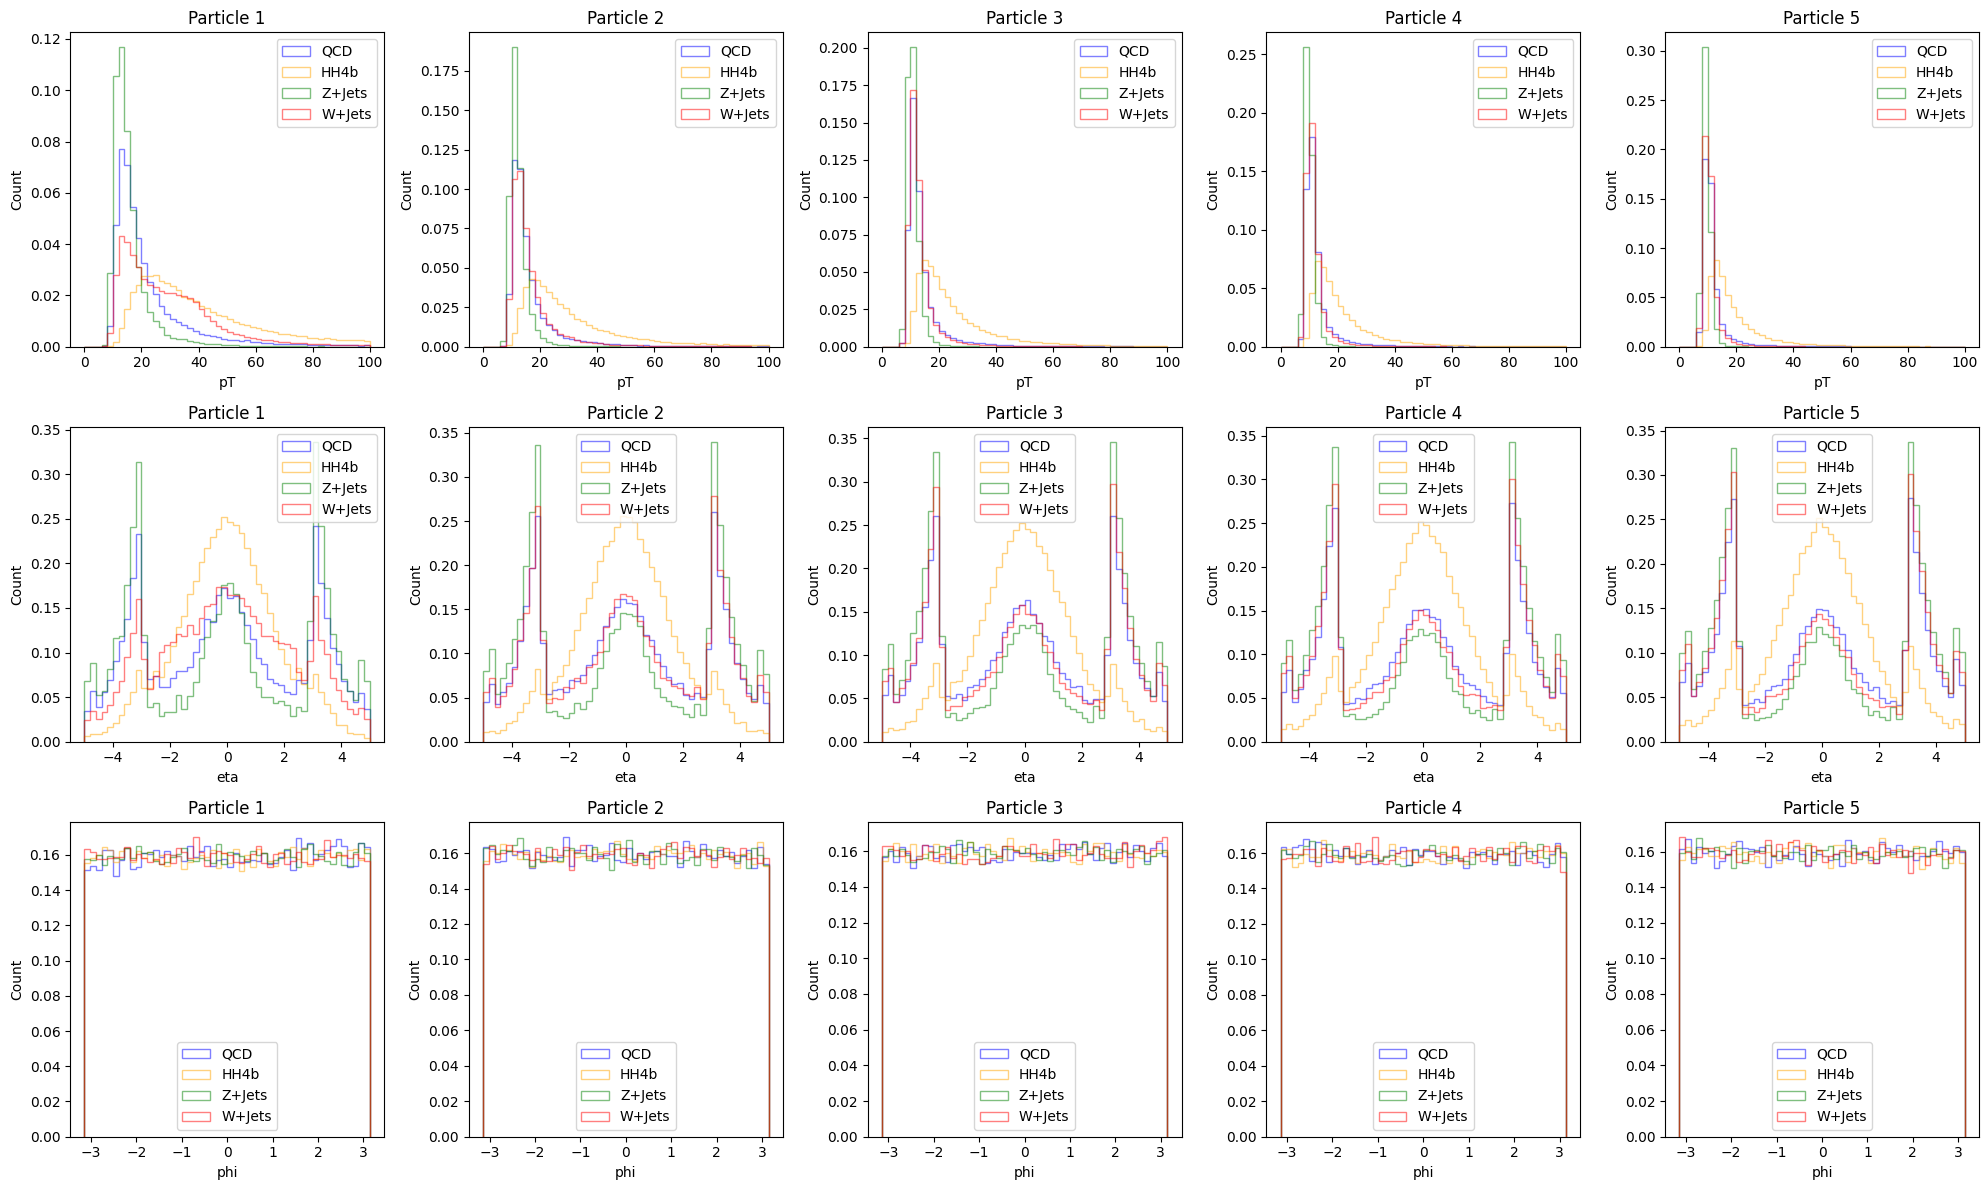

In [6]:
# Plot pT, eta and phi distributions for the five most energetic particles in each event, separated by class (5 x 3 plots)
num_particles_to_plot = 5
features_to_plot = [0, 1, 2]  # pT, eta, phi
feature_names = ['pT', 'eta', 'phi']
range_map = {
    0: (0, 100),   # pT range
    1: (-5, 5),    # eta range
    2: (-np.pi, np.pi)  # phi range
}

fig, axs = plt.subplots(len(features_to_plot), num_particles_to_plot, figsize=(20, 12))
for i, feature_idx in enumerate(features_to_plot):
    for j in range(num_particles_to_plot):
        ax = axs[i, j]
        for label, label_idx in label_map.items():
            # Extract the feature values for the j-th particle and the current feature index, for events of the current class
            feature_values = X[y == label_idx, j, feature_idx]
            ax.hist(feature_values, bins=50, range=range_map[feature_idx], alpha=0.5, histtype='step', label=label, density=True, color=color_map[label])
        ax.set_title(f"Particle {j+1}")
        ax.set_xlabel(feature_names[i])
        ax.set_ylabel("Count")
        ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Build the datasets for training and testing
# We will begin by using the top 16 most energetic particles. You should explore changing this and seeing how it affects the performance of your model
# Both in terms of accuracy and eventual resource usage when we get to the hardware implementation stage.
NUM_PARTICLES = 16
X_train, X_test, y_train, y_test = prep_physics_data(X, y, num_particles=NUM_PARTICLES, test_size=0.2, random_state=42)
print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

Train Shape: (301917, 16, 3) | Test Shape: (75480, 16, 3)


In [8]:
# Initialise the data loaders
# Particle level, so no flattening!
flatten = False

# We will also use a batch size of 512
train_loader = ParticleDataLoader(X_train, y_train, batch_size=512, flatten=flatten)
test_loader = ParticleDataLoader(X_test, y_test, batch_size=512, flatten=flatten)
print(f"DataLoader gives input shape: {train_loader[0][0].shape} and labels shape: {train_loader[0][1].shape}")

DataLoader gives input shape: (512, 16, 3) and labels shape: (512,)


In [9]:
input_shape = train_loader[0][0].shape[1]

In [10]:
# Configuration
NUM_CLASSES = 4

FF_DIM = 16
PROJ_K = 2
TARGET_EBOPS = 350000
NUM_FEATURES = 3

MODEL_DIR = "./models"
HLS_DIR = "./hls_projects"

# Create output directories if they don't exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(HLS_DIR, exist_ok=True)

print(f"Config: FF_DIM={FF_DIM}, PARTICLES={NUM_PARTICLES}, TARGET_EBOPS={TARGET_EBOPS}")

Config: FF_DIM=16, PARTICLES=16, TARGET_EBOPS=350000


In [11]:
def get_model(ff_dim=16, numheads=1, beta0=1e-10, num_particles=64, proj_k=2):
    # Quantization Scopes
    scope0 = QuantizerConfigScope(k0=1, b0=8, i0=1, br=MonoL1(1e-8), overflow_mode='WRAP')
    scope1 = QuantizerConfigScope(place='datalane', k0=1, f0=6, fr=MonoL1(1e-8), ir=MonoL1(1e-8))
    betascope = LayerConfigScope(beta0=beta0)

    # Linformer Attention Config
    mhaconfig = QuantizerConfigScope(
        k0=1, i0=1, f0=6, round_mode='RND', overflow_mode='SAT',
        bc=hgq.constraints.MinMax(1, 8)
    )

    with betascope, scope0, scope1:
        qkv = keras.layers.Input((num_particles, NUM_FEATURES))
        emb = QDense(ff_dim, activation='relu')(qkv)
        emb = QDense(ff_dim, activation='relu')(emb)

        with mhaconfig:
            x = QLinformerAttention(numheads, key_dim=ff_dim // numheads,
                     lin_kv_proj_dim=proj_k, name='attention1', dropout=0)(emb, emb, emb)

        res = QAdd()([x, emb])
        x = QDense(ff_dim * 2, activation='relu')(res)
        x = QDense(ff_dim, activation='relu')(x)
        res = QAdd()([x, res])

        x = QDense(ff_dim * 2, activation='relu')(res)
        x = QDense(ff_dim, activation='relu')(x)
        lo2 = QAdd()([x, res])

        x = GlobalAveragePooling1D(data_format='channels_last')(lo2)
        x = QDense(ff_dim, activation="relu")(x)
        out = QDense(NUM_CLASSES)(x)

    return keras.Model([qkv], out)

In [14]:


# PID Controller Settings
control_p = 1
control_i = 0.1
beta0 = 1e-10

# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.8, patience=50,
    min_lr=1e-5, cooldown=200, min_delta=0.05
)

es = EarlyStoppingWithEbopsThres(
    monitor="val_loss",
    patience=150,
    verbose=1,
    mode="min",
    restore_best_weights=True,
    start_from_epoch=75,
    ebops_threshold=TARGET_EBOPS + 100000
)

pbar = PBar('loss: {loss:.3f}/{val_loss:.3f} - acc: {accuracy:.3f}/{val_accuracy:.3f}')
ebops_tracker = FreeEBOPs()
nan_terminate = TerminateOnNaN()
ebops_scheduler = BetaPID(
    p=control_p, i=control_i, d=0,
    target_ebops=TARGET_EBOPS,
    init_beta=1e-10, warmup=10,
    max_beta=5e-6, damp_beta_on_target=0.5
)

callbacks = [ebops_tracker, pbar, nan_terminate, ebops_scheduler, reduce_lr, es]

# Build Model
model = get_model(ff_dim=FF_DIM, beta0=beta0, num_particles=NUM_PARTICLES, proj_k=PROJ_K)

loss_logits = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=AdamW(learning_rate=0.001),
    loss=loss_logits,
    metrics=["accuracy"],
    jit_compile=True,
    steps_per_execution=4
)

# Fit Model
try:
    history = model.fit(
        train_loader,
        validation_data=test_loader,
        epochs=10,
        callbacks=callbacks,
        verbose=0
    )

    best_epoch = np.argmax(history.history['val_accuracy'])
    model_final_acc = model.evaluate(test_loader, verbose=0)[-1]

    # Final Analysis
    ebops_sum = 0
    for layer in model.layers:
        if hasattr(layer, 'ebops'):
            print(f"{layer.name}: {layer.ebops}")
            ebops_sum += layer.ebops

    print(f"Total EBOps: {ebops_sum}")
    print(f"Final Test Accuracy: {model_final_acc:.4f}")

except Exception as e:
    print(f"Training failed: {e}")

loss: 0.959/0.954 - acc: 0.596/0.599 - EBOPs: 2,556,543: 100%|██████████| 10/10 [01:43<00:00, 10.37s/epoch]


q_dense_16: 51328
q_dense_17: 239209
attention1: 109319
q_add_6: 1151
q_dense_18: 388792
q_dense_19: 398366
q_add_7: 1249
q_dense_20: 430512
q_dense_21: 415141
q_add_8: 1388
q_dense_22: 17504
q_dense_23: 2460
Total EBOps: 2056419
Final Test Accuracy: 0.5988


## Inspect bitwidths

q_dense 136960
q_dense_1 373248
attention1 1388592
q_einsum_dense
'NoneType' object has no attribute 'bits'
q_einsum_dense_1
'NoneType' object has no attribute 'bits'
query
key
'NoneType' object has no attribute 'bits'
value
q_softmax
'QSoftmax' object has no attribute '_kq'
'QSoftmax' object has no attribute '_bq'
dropout
'Dropout' object has no attribute '_kq'
'Dropout' object has no attribute '_iq'
'Dropout' object has no attribute '_bq'
attention_output
q_add 1968
q_dense_2 797696
q_dense_3 608384
q_add_1 2100
q_dense_4 867072
q_dense_5 621824
q_add_2 2326
q_dense_6 14976
q_dense_7 2176


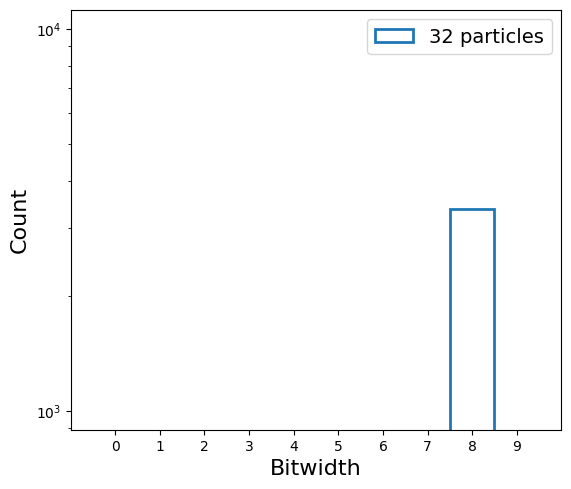

In [ ]:


plt.figure(figsize=(6,5))

bitwidths = []
for l in model.layers:
    if hasattr(l, "ebops"):
        print(l.name, l.ebops)
    if "attention" in l.name:
        for i in l._layers:
            try:
                print(i.name)
                bitwidths += list(i._kq.bits.flatten())
            except Exception as e:
                print(e)

            try:
                bitwidths += list(i._iq.bits.flatten())
            except Exception as e:
                print(e)
            try:
                bitwidths += list(i._bq.bits.flatten())
            except Exception as e:
                print(e)

plt.hist(bitwidths, histtype="step", linewidth=2, range=(-0.5, 9.5), bins=10 , label=f"{NUM_PARTICLES} particles")

#plt.grid(True, which="both", linestyle=':')
plt.xlabel('Bitwidth', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.tight_layout()
plt.xticks(np.arange(0,10,1), np.arange(0,10,1), minor=False)
plt.yscale("log")
plt.legend(fontsize=14)

plt.show()

input_layer
'InputLayer' object has no attribute 'kq'
q_dense 136960
q_dense
q_dense_1 373248
q_dense_1
attention1 1388592
q_add 1968
q_add
'QAdd' object has no attribute 'kq'
q_dense_2 797696
q_dense_2
q_dense_3 608384
q_dense_3
q_add_1 2100
q_add_1
'QAdd' object has no attribute 'kq'
q_dense_4 867072
q_dense_4
q_dense_5 621824
q_dense_5
q_add_2 2326
q_add_2
'QAdd' object has no attribute 'kq'
global_average_pooling1d
'GlobalAveragePooling1D' object has no attribute 'kq'
q_dense_6 14976
q_dense_6
q_dense_7 2176
q_dense_7


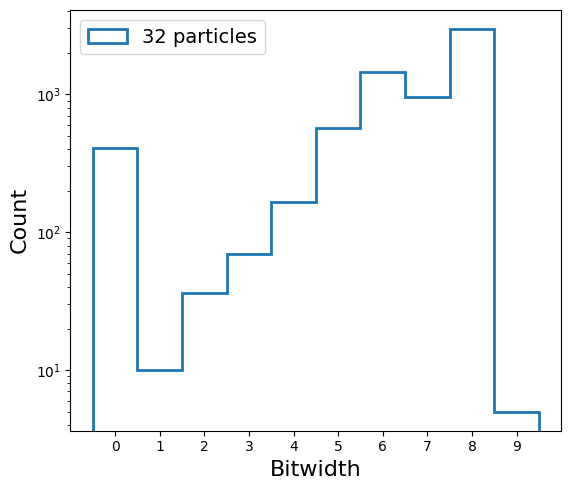

In [ ]:

plt.figure(figsize=(6,5))


bitwidths = []
for l in model.layers:
    if hasattr(l, "ebops"):
        print(l.name, l.ebops)
    if "attention" not in l.name:
        print(l.name)
        try:
            bitwidths += list(l.kq.bits.flatten())
            bitwidths += list(l.iq.bits.flatten())
            bitwidths += list(l.bq.bits.flatten())
        except Exception as e:
            print(e)


plt.hist(bitwidths, histtype="step", linewidth=2, range=(-0.5, 9.5), bins=10 , label=f"{NUM_PARTICLES} particles")

#plt.grid(True, which="both", linestyle=':')
plt.xlabel('Bitwidth', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.tight_layout()
plt.xticks(np.arange(0,10,1), np.arange(0,10,1))
plt.yscale("log")
plt.legend(fontsize=14)

plt.show()


# Convert to HLS (using vivado backend)
## hls4ml + da
## Note: no synthesis included
*    Large model synthesis takes hours and >100G of RAM

In [ ]:
ebops_sum = 0
for layer in model.layers:
    if hasattr(layer, 'ebops'):
        print(layer.name, layer.ebops)
        ebops_sum += layer.ebops

print("Model ebops:", ebops_sum)

q_dense 136960
q_dense_1 373248
attention1 1388592
q_add 1968
q_dense_2 797696
q_dense_3 608384
q_add_1 2100
q_dense_4 867072
q_dense_5 621824
q_add_2 2326
q_dense_6 14976
q_dense_7 2176
Model ebops: 4817322


In [ ]:
import hls4ml
from hgq.utils import trace_minmax, dataset



print("Creating Dataset from existing X_val")

test_data = dataset.Dataset(X_val, device="gpu:0", batch_size=1024)

# Construct relative output directory name using global variables
dir_name = f"hls4ml_out"
out_dir_base = os.path.join(HLS_DIR, dir_name)

print(f"Target Part: xcu250-figd2104-2L-e")
print(f"Output Base Directory: {out_dir_base}")

# Create Dataset using existing training arrays

# Conversion 1: Basic Configuration
print("Generating Basic HLS Project...")
hls_config_basic = {
    'Model': {
        'Precision': 'ap_fixed<1,0>',
        'ReuseFactor': 1
    }
}

model_hls = hls4ml.converters.convert_from_keras_model(
    model,
    output_dir=out_dir_base + "_basic",
    io_type='io_parallel',
    part='xcu250-figd2104-2L-e',
    hls_config=hls_config_basic
)

model_hls.write()
print(f"Basic project written to: {out_dir_base}_basic")

# Conversion 2: Distributed Arithmetic (DA) Configuration
print("Generating Distributed Arithmetic (DA) HLS Project...")
hls_config_da = {
    'Model': {
        'Strategy': 'distributed_arithmetic',
        'Precision': 'ap_fixed<1,0>',
        'ReuseFactor': 1
    }
}

model_hls_da = hls4ml.converters.convert_from_keras_model(
    model,
    output_dir=out_dir_base + "_basic_da",
    part='xcu250-figd2104-2L-e',
    io_type='io_parallel',
    hls_config=hls_config_da
)

model_hls_da.write()
print(f"DA project written to: {out_dir_base}_basic_da")



# Use tracing to reduce the bitwidths

trace_minmax(model, test_data, verbose=True)


model_hls = hls4ml.converters.convert_from_keras_model(model, output_dir=out_dir_base+"_traced",
                                     io_type='io_parallel',
                                     part='xcu250-figd2104-2L-e',
                                     hls_config={'Model': {'Precision': 'ap_fixed<1,0>', 'ReuseFactor': 1}})

model_hls.write()

hls_config_da={'Model': {'Strategy': 'distributed_arithmetic', 'Precision': 'ap_fixed<1,0>', 'ReuseFactor': 1}}
model_hls_da = hls4ml.converters.convert_from_keras_model(model,
                                        output_dir=out_dir_base + "_traced_da",
                                        part='xcu250-figd2104-2L-e',
                                        io_type='io_parallel', hls_config=hls_config_da)
model_hls_da.write()






Creating Dataset from existing X_val
Target Part: xcu250-figd2104-2L-e
Output Base Directory: ./hls_projects/hls4ml_out
Generating Basic HLS Project...
Basic project written to: ./hls_projects/hls4ml_out_basic
Generating Distributed Arithmetic (DA) HLS Project...
DA project written to: ./hls_projects/hls4ml_out_basic_da


q_dense   : 136960
q_dense_1 : 372992
attention1: 1388592
q_add     : 1924
q_dense_2 : 781568
q_dense_3 : 600064
q_add_1   : 2070
q_dense_4 : 864256
q_dense_5 : 620288
q_add_2   : 2328
q_dense_6 : 14848
q_dense_7 : 2048
Total: 4787938


In [ ]:
!ls hls_projects/*

hls_projects/hls4ml_out_basic:
build_lib.sh   hls4ml_config.yml     myproject_test.cpp  vivado_synth.tcl
build_prj.tcl  keras_model.keras     project.tcl
firmware       myproject_bridge.cpp  tb_data

hls_projects/hls4ml_out_basic_da_fixed:
build_lib.sh   hls4ml_config.yml     myproject_test.cpp  vivado_synth.tcl
build_prj.tcl  keras_model.keras     project.tcl
firmware       myproject_bridge.cpp  tb_data

hls_projects/hls4ml_out_traced:
build_lib.sh   hls4ml_config.yml     myproject_test.cpp  vivado_synth.tcl
build_prj.tcl  keras_model.keras     project.tcl
firmware       myproject_bridge.cpp  tb_data

hls_projects/hls4ml_out_traced_da:
build_lib.sh   hls4ml_config.yml     myproject_test.cpp  vivado_synth.tcl
build_prj.tcl  keras_model.keras     project.tcl
firmware       myproject_bridge.cpp  tb_data


# Graph networks using JEDI-Linear

https://arxiv.org/pdf/2508.15468

## JEDI-net

https://arxiv.org/pdf/2209.14065

*   Particle interactions as graph
*   Inefficient scaling as particle count increases



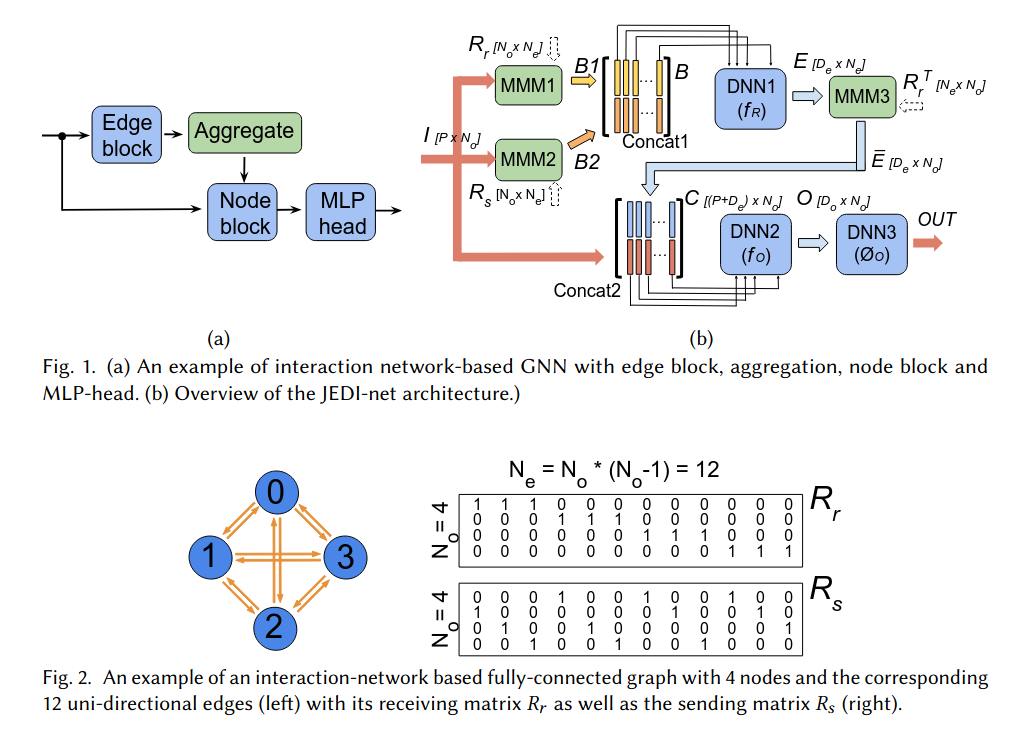

# JEDI-linear

*    Efficient graphs for FPGAs
*    CMVM instead of MMM

Assume the edge projecting is a affine:

 $f_R(I_i \| I_j)_{l} = W \left(I_i \| I_j\right) + C = W_1 I_i + W_2 I_j + C$

$ \bar{E}_i = \sum_{j} f_R(I_i \| I_j) $

$ = \sum_{j\ne i}\left(W_1 I_i + W_2 I_j + C\right) $

$ = W_2 \sum_{j}\left(I_j\right) - I_i + \left(N_O-1\right)\left(W_1 I_i + C\right) $

$ = W_2\frac1{N_O} \sum_{j}\left(I_j\right) - \frac{I_i}{N_O} + \frac {N_O-1}{N_O}\left(W_1 I_i + C\right) $

$ \approx W_2 \frac1{N_O} \sum_{j}\left(I_j\right) + W_1 I_i + C $

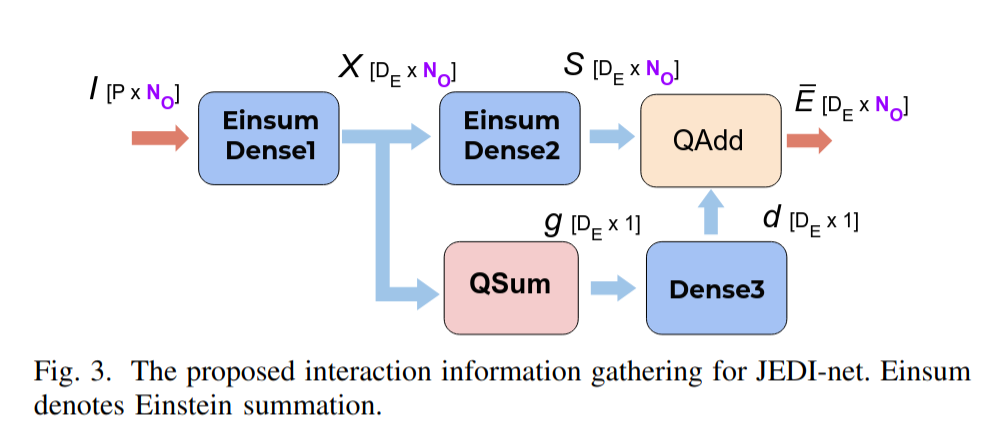

In [ ]:
import math

def get_jedi_model(N=32):
    # Quantization Scopes
    scope0 = QuantizerConfigScope(k0=1, b0=8, i0=1, br=MonoL1(1e-8), overflow_mode='WRAP')
    scope1 = QuantizerConfigScope(place='datalane', k0=1, f0=6, fr=MonoL1(1e-8), ir=MonoL1(1e-8))
    betascope = LayerConfigScope(beta0=beta0)


    with betascope, scope0, scope1:

        inp = keras.layers.Input((N, NUM_FEATURES))

        pool_scale = 2.0 ** -round(math.log2(N))
        x = QEinsumDenseBatchnorm(
            'bnc,cC->bnC', (N, 64), bias_axes='C', activation='relu'
        )(inp)
        s = QEinsumDenseBatchnorm(
            'bnc,cC->bnC',
            (N, 64),
            bias_axes='C',
            activation='relu',
        )(x)
        d = QEinsumDenseBatchnorm(
            'bnc,cC->bnC', (1, 64), bias_axes='C', activation='relu'
        )(QSum(axes=1, scale=pool_scale, keepdims=True)(x))
        x = QAdd()([s, d])

        x = QEinsumDenseBatchnorm(
            'bnc,cC->bnC',
            (N, 64),
            bias_axes='C',
            activation='relu',
        )(x)
        x = QSum(axes=1, scale=1 / 16, keepdims=False)(x)
        x = QEinsumDenseBatchnorm('bc,cC->bC', 64, bias_axes='C', activation='relu')(x)
        x = QEinsumDenseBatchnorm('bc,cC->bC', 32, bias_axes='C', activation='relu')(x)
        x = QEinsumDenseBatchnorm('bc,cC->bC', 16, bias_axes='C', activation='relu')(x)
        out = QEinsumDenseBatchnorm('bc,cC->bC', NUM_CLASSES, bias_axes='C')(x)

    model = keras.Model(inputs=inp, outputs=out)

    return model

# Exercise: train and convert Jedi-linear (da4ml)

In [ ]:
model = get_jedi_model()

In [ ]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 32, 64)    │      2,213 │ input_layer_4[0]… │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_sum_4 (QSum)      │ (None, 1, 64)     │      6,147 │ q_einsum_dense_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 32, 64)    │     22,981 │ q_einsum_dense_b… │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 1, 64)     │     17,029 │ q_sum_4[0][0]     │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_add_8 (QAdd)      │ (None, 32, 64)    │      6,340 │ q_einsum_dense_b… │
│                     │                   │            │ q_einsum_dense_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 32, 64)    │     22,981 │ q_add_8[0][0]     │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_sum_5 (QSum)      │ (None, 64)        │      6,147 │ q_einsum_dense_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 64)        │     17,029 │ q_sum_5[0][0]     │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 32)        │      8,613 │ q_einsum_dense_b… │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 16)        │      2,261 │ q_einsum_dense_b… │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 4)         │        337 │ q_einsum_dense_b… │
│ (QEinsumDenseBatch… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 112,078 (348.73 KB)

 Trainable params: 50,476 (197.17 KB)

 Non-trainable params: 61,602 (151.56 KB)

# da4ml conversion only

In [ ]:
from da4ml.converter import trace_model
from da4ml.trace import comb_trace
from da4ml.codegen import RTLModel

In [ ]:
os.makedirs('/tmp/projects', exist_ok=True)

In [ ]:

_inp, _out = trace_model(model)
comb_logic = comb_trace(_inp, _out)


rtl_model = RTLModel(comb_logic, 'jedilinear', f'/tmp/projects/output', latency_cutoff=1, clock_period=1, clock_uncertainty=0)




In [ ]:
rtl_model.write()

## Convert with da4ml

In [ ]:
inp, out = trace_model(model)
comb_logic = comb_trace(inp, out)
rtl_model = RTLModel(comb_logic, 'vmodel', '/tmp/rtl', flavor='verilog', latency_cutoff=5) # can also be HLSModel
rtl_model.write()